# Week 6 — Local Atomic Environments & the Descriptor Ladder

**SS26 Materials Genomics, FAU Erlangen (Prof. Pelz).**
Exercise notebook for Unit 6. Climb the descriptor ladder on a
~220-row Materials Project spinel subset:

| Tier | Descriptor                              | Library    | Cells |
|------|-----------------------------------------|------------|-------|
| 1    | Magpie composition statistics           | matminer   | Part 1 |
| 2    | matminer structure features (CrystalNN, BondFractions) | matminer | Part 2 |
| 3    | SOAP (atom-centred, smooth)             | dscribe    | Part 3 |
| --   | Permutation-importance + leakage audit  | scikit-learn | Part 4 |

**Target.** PBE band gap (eV) from `matbench_mp_gap`. The CSV is shipped
in this folder (`spinels_mp.csv`, 220 entries, AB$_2$O$_4$ stoichiometry,
115 distinct formulas, 105 of them with two polymorphs).

**Time budget.** 90 minutes total — 5 setup / 25 Part 1 / 25 Part 2 /
25 Part 3 / 15 Part 4. Parts 1–4 each re-load from the CSV in their
opening cell, so you can skip ahead if you fall behind.

## Part 0 — Setup (≈5 min)

Imports, version check, dataset load, sanity sniff.

In [1]:
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler

from pymatgen.core import Composition, Structure

from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.site import CrystalNNFingerprint
from matminer.featurizers.structure import (
    BondFractions,
    SiteStatsFingerprint,
)

from dscribe.descriptors import SOAP

RNG = 0
np.random.seed(RNG)

In [2]:
from importlib.metadata import version as _v

for pkg in ['numpy', 'pandas', 'matplotlib', 'scikit-learn',
            'pymatgen', 'matminer', 'dscribe']:
    try:
        print(f'{pkg:15s} {_v(pkg)}')
    except Exception as e:
        print(f'{pkg:15s} NOT INSTALLED ({e})')

numpy           1.26.4
pandas          2.3.0
matplotlib      3.10.3
scikit-learn    1.7.0
pymatgen        2026.5.4
matminer        0.10.1
dscribe         2.1.2


In [3]:
CSV = Path('spinels_mp.csv')
assert CSV.exists(), f'expected {CSV.resolve()} — see README_week06.md'

df = pd.read_csv(CSV)
df['structure'] = df['structure'].apply(lambda s: Structure.from_dict(json.loads(s)))
df['composition'] = df['pretty_formula'].apply(Composition)

print(f'dataset size:           {len(df)}')
print(f'unique formulas:        {df.pretty_formula.nunique()}')
print(f'polymorph-formulas:     {int((df.pretty_formula.value_counts() >= 2).sum())}')
print(f'band-gap range (eV):    [{df.band_gap.min():.2f}, {df.band_gap.max():.2f}]')
print(f'mean band gap:          {df.band_gap.mean():.3f} eV')
df.head(3)[['material_id', 'pretty_formula', 'band_gap', 'spacegroup']]

dataset size:           220
unique formulas:        115
polymorph-formulas:     105
band-gap range (eV):    [0.00, 5.11]
mean band gap:          1.241 eV


,material_id,pretty_formula,band_gap,spacegroup
0,mb_mpgap_0000,MgMn2O4,0.5791,13
1,mb_mpgap_0001,MgMn2O4,0.7655,14
2,mb_mpgap_0002,CaMn2O4,1.2826,141


In [4]:
# Sniff one structure to confirm round-trip.
ex = df.iloc[0]
print(f"{ex.pretty_formula}  (spacegroup {ex.spacegroup}, gap {ex.band_gap:.2f} eV)")
print(ex.structure)

MgMn2O4  (spacegroup 13, gap 0.58 eV)
Full Formula (Mg4 Mn8 O16)
Reduced Formula: MgMn2O4
abc   :   6.026773   5.150628  11.768915
angles:  90.000000 119.066959  90.000000
pbc   :       True       True       True
Sites (28)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Mg    0         0.148683  0.75
  1  Mg    0         0.851317  0.25
  2  Mg    0.5       0.511308  0.25
  3  Mg    0.5       0.488692  0.75
  4  Mn    0.765334  0.488393  0.015557
  5  Mn    0.234666  0.488393  0.484443
  6  Mn    0.234666  0.511607  0.984443
  7  Mn    0.765334  0.511607  0.515557
  8  Mn    0.5       0         0
  9  Mn    0.5       0         0.5
 10  Mn    0         0         0
 11  Mn    0         0         0.5
 12  O     0.843053  0.141912  0.101583
 13  O     0.156947  0.141912  0.398417
 14  O     0.156947  0.858088  0.898417
 15  O     0.843053  0.858088  0.601583
 16  O     0.649467  0.76553   0.896718
 17  O     0.350533  0.76553   0.603282
 18  O     0.350

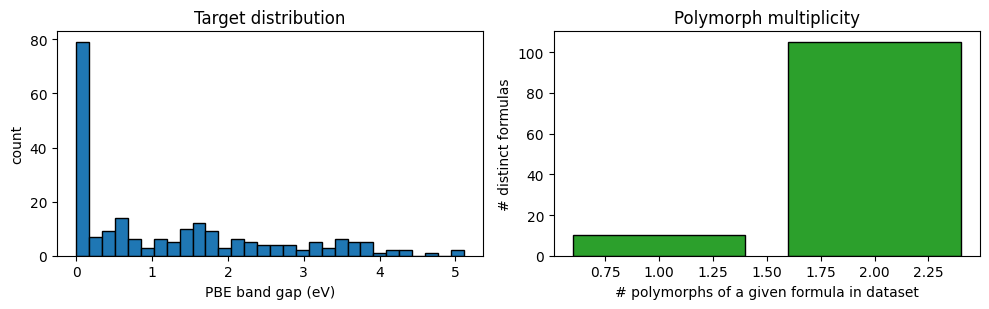

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(df['band_gap'], bins=30, color='C0', edgecolor='k')
ax[0].set_xlabel('PBE band gap (eV)'); ax[0].set_ylabel('count')
ax[0].set_title('Target distribution')

poly_counts = df.pretty_formula.value_counts().value_counts().sort_index()
ax[1].bar(poly_counts.index.astype(int), poly_counts.values, color='C2', edgecolor='k')
ax[1].set_xlabel('# polymorphs of a given formula in dataset')
ax[1].set_ylabel('# distinct formulas')
ax[1].set_title('Polymorph multiplicity')
plt.tight_layout(); plt.show()

**Why the polymorph-multiplicity histogram matters.**
105 of the 115 distinct formulas appear with two structural polymorphs.
That makes this dataset a *miniature stress test* for the polymorph-leakage
audit in Part 4: a naive row-wise train/test split will put one polymorph
of MgMn$_2$O$_4$ in train and the other in test — and the model will look
better than it really is. We will keep the splits *grouped by formula*
throughout Parts 1–3 and break that rule deliberately in Part 4.

In [6]:
# Container for results across all parts — populated as we go.
results: dict[str, dict] = {}

def report(name: str, mae: float, t_train: float, n_features: int) -> None:
    results[name] = dict(mae=mae, t_train=t_train, n_features=n_features)
    print(f'{name:22s}  MAE = {mae:.3f} eV   '
          f'train = {t_train:6.2f}s   features = {n_features}')

## Part 1 — Magpie composition baseline  (≈25 min, must-finish)

Magpie elemental statistics (Ward 2016) are the *tier-1* descriptor:
they ignore structure entirely and just summarise the elements present.
For bulk-thermodynamic targets this is embarrassingly competitive — and
it is the floor every structure-aware claim should clear before
celebrating.

We split **by formula group** so that polymorphs of the same compound
can never land in both train and test. `GroupShuffleSplit` on
`pretty_formula` does exactly that.

In [7]:
# This cell is self-contained: it reloads the CSV so Part 1 runs even
# if you skipped Part 0. (Each Part has the same idiom.)
if 'df' not in globals():
    df_local = pd.read_csv('spinels_mp.csv')
    df_local['structure'] = df_local['structure'].apply(
        lambda s: Structure.from_dict(json.loads(s)))
    df_local['composition'] = df_local['pretty_formula'].apply(Composition)
else:
    df_local = df

ep = ElementProperty.from_preset('magpie')
print(f'Magpie produces {len(ep.feature_labels())} features per composition.')

t0 = time.perf_counter()
X_magpie = ep.featurize_many(df_local['composition'].tolist(),
                              ignore_errors=True, pbar=False)
X_magpie = np.array(X_magpie, dtype=float)
print(f'featurise time: {time.perf_counter() - t0:.1f}s')
print(f'feature matrix: {X_magpie.shape}')

Magpie produces 132 features per composition.


featurise time: 0.4s
feature matrix: (220, 132)


In [8]:
# Drop any all-NaN columns (rare; matminer can return NaN for elements
# with missing tabulated properties — none for d-block oxides, but be safe).
finite_mask = np.isfinite(X_magpie).all(axis=0)
X_magpie = X_magpie[:, finite_mask]
magpie_names = [n for n, k in zip(ep.feature_labels(), finite_mask) if k]
y = df_local['band_gap'].to_numpy()
groups = df_local['pretty_formula'].to_numpy()
print(f'after NaN-column drop: {X_magpie.shape}')

after NaN-column drop: (220, 132)


In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RNG)
train_idx, test_idx = next(gss.split(X_magpie, y, groups=groups))

# Verify no formula leaks across the split.
train_formulas = set(groups[train_idx])
test_formulas = set(groups[test_idx])
leak = train_formulas & test_formulas
print(f'train: {len(train_idx)}  test: {len(test_idx)}')
print(f'leak (formulas in both): {len(leak)}  (must be 0)')
assert len(leak) == 0

train: 165  test: 55
leak (formulas in both): 0  (must be 0)


In [10]:
t0 = time.perf_counter()
rf1 = RandomForestRegressor(n_estimators=200, random_state=RNG, n_jobs=-1)
rf1.fit(X_magpie[train_idx], y[train_idx])
t_train_1 = time.perf_counter() - t0

y_pred_1 = rf1.predict(X_magpie[test_idx])
MAE_1 = mean_absolute_error(y[test_idx], y_pred_1)
report('1 Magpie comp', MAE_1, t_train_1, X_magpie.shape[1])

1 Magpie comp           MAE = 0.669 eV   train =   0.48s   features = 132


**Checkpoint.** If your `MAE_1` is much below **0.6 eV**, your split
is probably leaking — verify the assert two cells above. Typical numbers
on this dataset under a *grouped* split are 0.7–0.9 eV; a *random* split
collapses this to 0.4–0.5 eV by spotting the formula directly. We will
prove that drop is illusory in Part 4.

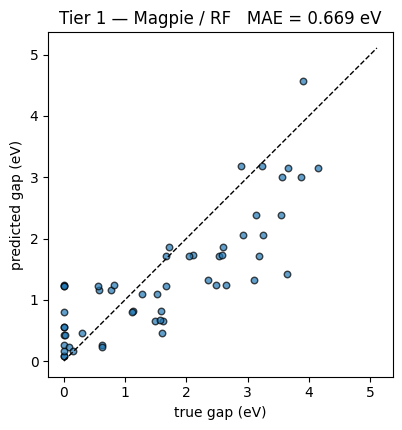

In [11]:
fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.scatter(y[test_idx], y_pred_1, alpha=0.7, edgecolor='k', s=22)
lo, hi = y.min(), y.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel('true gap (eV)'); ax.set_ylabel('predicted gap (eV)')
ax.set_title(f'Tier 1 — Magpie / RF   MAE = {MAE_1:.3f} eV')
ax.set_aspect('equal'); plt.tight_layout(); plt.show()

## Part 2 — Add matminer structure features  (≈25 min, stretch)

Tier 2 climbs one rung: we keep Magpie, but *also* aggregate per-site
geometry into structure-level features.

* `SiteStatsFingerprint` over `CrystalNNFingerprint("ops")` — coordination
  / order-parameter statistics per site, then mean+std-pooled over the
  structure. ~122 features.
* `BondFractions` — fractional populations of element-pair bonds.

The point: same Magpie vector for all polymorphs of MgMn$_2$O$_4$, but
*different* structure-feature vectors. If structure is doing real work
on this dataset, the MAE should drop.

In [12]:
if 'df' not in globals():
    df_local = pd.read_csv('spinels_mp.csv')
    df_local['structure'] = df_local['structure'].apply(
        lambda s: Structure.from_dict(json.loads(s)))
    df_local['composition'] = df_local['pretty_formula'].apply(Composition)
else:
    df_local = df

structs = df_local['structure'].tolist()
y = df_local['band_gap'].to_numpy()
groups = df_local['pretty_formula'].to_numpy()

In [13]:
# CrystalNNFingerprint("ops") site-fingerprint → mean/std pooled per structure.
ssf = SiteStatsFingerprint(
    CrystalNNFingerprint.from_preset('ops'),
    stats=('mean', 'std_dev'),
)
ssf.set_n_jobs(1)  # CrystalNN can hit thread-safety bugs in parallel

t0 = time.perf_counter()
X_ssf = ssf.featurize_many(structs, ignore_errors=True, pbar=False)
X_ssf = np.array(X_ssf, dtype=float)
print(f'SiteStatsFingerprint: {time.perf_counter() - t0:.1f}s, shape {X_ssf.shape}')

SiteStatsFingerprint: 53.7s, shape (220, 122)


In [14]:
# BondFractions — but only after the featurizer has *seen* the dataset
# (it must enumerate the bond vocabulary first).
bf = BondFractions()
bf.fit(structs)
bf.set_n_jobs(1)

t0 = time.perf_counter()
X_bf = bf.featurize_many(structs, ignore_errors=True, pbar=False)
X_bf = np.array(X_bf, dtype=float)
print(f'BondFractions: {time.perf_counter() - t0:.1f}s, shape {X_bf.shape}')

BondFractions: 25.9s, shape (220, 214)


In [15]:
# Stack: Magpie + CrystalNN-OPs + BondFractions.
X_struct = np.hstack([X_magpie, X_ssf, X_bf])
struct_names = (
    magpie_names
    + [f'ssf::{n}' for n in ssf.feature_labels()]
    + [f'bf::{n}' for n in bf.feature_labels()]
)
finite = np.isfinite(X_struct).all(axis=0)
X_struct = X_struct[:, finite]
struct_names = [n for n, k in zip(struct_names, finite) if k]
print(f'combined feature matrix: {X_struct.shape}')

combined feature matrix: (220, 468)


In [16]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RNG)
train_idx, test_idx = next(gss.split(X_struct, y, groups=groups))

t0 = time.perf_counter()
rf2 = RandomForestRegressor(n_estimators=200, random_state=RNG, n_jobs=-1)
rf2.fit(X_struct[train_idx], y[train_idx])
t_train_2 = time.perf_counter() - t0

y_pred_2 = rf2.predict(X_struct[test_idx])
MAE_2 = mean_absolute_error(y[test_idx], y_pred_2)
report('2 Magpie+struct', MAE_2, t_train_2, X_struct.shape[1])

2 Magpie+struct         MAE = 0.748 eV   train =   0.25s   features = 468


**Worked example — same formula, different structure.**
The dataset is built so that most formulas appear twice. The cell below
picks one such formula, prints the two polymorphs' (spacegroup, band
gap), and prints Tier-1 and Tier-2 predictions for each. Tier 1 collapses
to a single value (the Magpie vector is identical for both rows); Tier 2
*can* separate them — if structure features are doing useful work.

In [17]:
vc = df_local['pretty_formula'].value_counts()
poly_formulas = vc[vc >= 2].index.tolist()

# Pick the first formula whose two polymorphs straddle a band-gap gap.
chosen = None
for f in poly_formulas:
    rows = df_local[df_local['pretty_formula'] == f]
    if rows['band_gap'].max() - rows['band_gap'].min() > 0.5:
        chosen = f
        break
chosen = chosen or poly_formulas[0]
print(f'Polymorph pair: {chosen}\n')

rows = df_local[df_local['pretty_formula'] == chosen]
rows_idx = rows.index.to_numpy()
p1 = rf1.predict(X_magpie[rows_idx])
p2 = rf2.predict(X_struct[rows_idx])

out = rows[['material_id', 'spacegroup', 'band_gap']].copy()
out['pred_tier1_magpie']   = np.round(p1, 3)
out['pred_tier2_struct']   = np.round(p2, 3)
out

Polymorph pair: YMn2O4



,material_id,spacegroup,band_gap,pred_tier1_magpie,pred_tier2_struct
202,mb_mpgap_0202,15,1.1057,0.796,0.727
203,mb_mpgap_0203,166,0.0000,0.796,0.569


## Part 3 — SOAP via dscribe  (≈25 min, reach goal)

Tier 3 looks at the local atomic environment of each site. SOAP
(Bartók et al. 2013) expands the smooth neighbour density around an
atom into radial basis × spherical harmonics and forms a rotation-
invariant power spectrum. We pass `average="inner"` so dscribe returns
*one vector per structure* (averaging the rotation-invariant power
spectrum across sites is itself rotation-invariant).

In [18]:
if 'df' not in globals():
    df_local = pd.read_csv('spinels_mp.csv')
    df_local['structure'] = df_local['structure'].apply(
        lambda s: Structure.from_dict(json.loads(s)))
else:
    df_local = df

structs = df_local['structure'].tolist()
y = df_local['band_gap'].to_numpy()
groups = df_local['pretty_formula'].to_numpy()

# Universe of species across the dataset (SOAP needs a fixed alphabet).
species = sorted({el.symbol for s in structs for el in s.composition.elements})
print(f'{len(species)} species in dataset: {species}')

50 species in dataset: ['Ag', 'Al', 'Au', 'Ba', 'Be', 'Bi', 'Ca', 'Cd', 'Ce', 'Co', 'Cr', 'Cu', 'Dy', 'Eu', 'Fe', 'Ga', 'Gd', 'H', 'In', 'K', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'Na', 'Nb', 'Nd', 'Ni', 'O', 'Pr', 'Rb', 'Rh', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Te', 'Ti', 'Tl', 'Tm', 'U', 'V', 'Y', 'Zn', 'Zr']


In [19]:
# pymatgen Structure → ase.Atoms for dscribe.
from pymatgen.io.ase import AseAtomsAdaptor

ase_adaptor = AseAtomsAdaptor()
atoms_list = [ase_adaptor.get_atoms(s) for s in structs]
print(f'converted {len(atoms_list)} structures to ase.Atoms')

converted 220 structures to ase.Atoms


In [20]:
soap = SOAP(
    species=species,
    r_cut=5.0,
    n_max=6,
    l_max=4,
    periodic=True,
    average='inner',
    sparse=False,
)
print(f'SOAP descriptor dimension per structure: {soap.get_number_of_features()}')

t0 = time.perf_counter()
X_soap = soap.create(atoms_list, n_jobs=1)
t_soap = time.perf_counter() - t0
print(f'SOAP compute: {t_soap:.1f}s, shape {X_soap.shape}')

SOAP descriptor dimension per structure: 225750


SOAP compute: 1.2s, shape (220, 225750)


In [21]:
# PCA-reduce: SOAP is high-dimensional and most directions carry no signal
# on a 220-row dataset. 64 components is a sensible default.
scaler = StandardScaler()
X_soap_s = scaler.fit_transform(X_soap)
n_pca = min(64, X_soap_s.shape[0] - 1, X_soap_s.shape[1])
pca = PCA(n_components=n_pca, random_state=RNG)
X_soap_pca = pca.fit_transform(X_soap_s)
print(f'PCA-reduced SOAP shape: {X_soap_pca.shape}')
print(f'explained variance (cumulative): {pca.explained_variance_ratio_.sum():.3f}')

PCA-reduced SOAP shape: (220, 64)
explained variance (cumulative): 0.553


In [22]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RNG)
train_idx, test_idx = next(gss.split(X_soap_pca, y, groups=groups))

# (a) Kernel ridge with an RBF on SOAP-PCA.
t0 = time.perf_counter()
krr = KernelRidge(kernel='rbf', alpha=1e-2, gamma=1.0 / X_soap_pca.shape[1])
krr.fit(X_soap_pca[train_idx], y[train_idx])
t_train_3a = time.perf_counter() - t0
y_pred_3a = krr.predict(X_soap_pca[test_idx])
MAE_3a = mean_absolute_error(y[test_idx], y_pred_3a)
report('3a SOAP / KRR', MAE_3a, t_train_3a, X_soap_pca.shape[1])

# (b) Random forest on the same SOAP-PCA features, for apples-to-apples.
t0 = time.perf_counter()
rf3 = RandomForestRegressor(n_estimators=200, random_state=RNG, n_jobs=-1)
rf3.fit(X_soap_pca[train_idx], y[train_idx])
t_train_3b = time.perf_counter() - t0
y_pred_3b = rf3.predict(X_soap_pca[test_idx])
MAE_3b = mean_absolute_error(y[test_idx], y_pred_3b)
report('3b SOAP / RF', MAE_3b, t_train_3b, X_soap_pca.shape[1])

3a SOAP / KRR           MAE = 1.634 eV   train =   0.01s   features = 64


3b SOAP / RF            MAE = 1.030 eV   train =   0.24s   features = 64


**Observation, to discuss in your write-up.**

SOAP captures the *local* atomic environment: who sits next to whom at
what radial+angular distribution. matminer's `SiteStatsFingerprint`
captures *aggregate per-site statistics* — coarser but cheaper. Which
won on this dataset? If SOAP did **not** beat Tier 2, that is a
teaching moment too: the spinel subset is *composition-dominated* (only
115 distinct formulas, narrow chemistry), and structure-information
adds little once you have decent composition+coordination features.

That is the whole point of climbing the descriptor ladder one rung at a
time and *reporting every rung*.

## Part 4 — Audit  (≈15 min, critical)

This is the part that separates careful work from confident-looking
nonsense. Three checks:

1. **Permutation importance** on the best Tier-1/2/3 model — does the
   dominant feature make physical sense?
2. **Polymorph leakage** — what happens if you replace
   `GroupShuffleSplit` with a row-wise `train_test_split`?
3. **Tier table** — collect MAEs and training times into a single
   table, save to `results.csv`.

### 4.1 Permutation importance on the best model

We probe whichever model gave the lowest test MAE.

best model: 1 Magpie comp


permutation-importance time: 6.5s


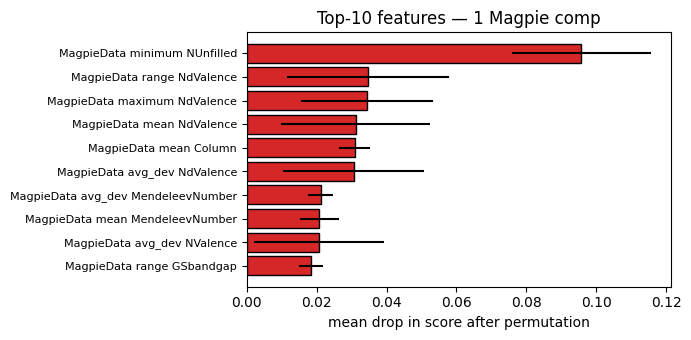

In [23]:
best_name = min(['1 Magpie comp', '2 Magpie+struct', '3a SOAP / KRR', '3b SOAP / RF'],
                key=lambda k: results[k]['mae'])
print(f'best model: {best_name}')

if best_name == '1 Magpie comp':
    X_best, model_best, names_best = X_magpie, rf1, magpie_names
elif best_name == '2 Magpie+struct':
    X_best, model_best, names_best = X_struct, rf2, struct_names
elif best_name == '3a SOAP / KRR':
    X_best, model_best, names_best = X_soap_pca, krr, [f'soap_pc{i}' for i in range(X_soap_pca.shape[1])]
else:
    X_best, model_best, names_best = X_soap_pca, rf3, [f'soap_pc{i}' for i in range(X_soap_pca.shape[1])]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RNG)
train_idx, test_idx = next(gss.split(X_best, y, groups=groups))

t0 = time.perf_counter()
pi = permutation_importance(model_best, X_best[test_idx], y[test_idx],
                             n_repeats=8, random_state=RNG, n_jobs=-1)
print(f'permutation-importance time: {time.perf_counter() - t0:.1f}s')

order = np.argsort(pi.importances_mean)[::-1][:10]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(range(len(order)),
        pi.importances_mean[order][::-1],
        xerr=pi.importances_std[order][::-1],
        color='C3', edgecolor='k')
ax.set_yticks(range(len(order)))
ax.set_yticklabels([names_best[i] for i in order[::-1]], fontsize=8)
ax.set_xlabel('mean drop in score after permutation')
ax.set_title(f'Top-10 features — {best_name}')
plt.tight_layout(); plt.show()

### 4.2 TODO — interpret the importance plot

**TODO.** Look at the top 5 features above and write 2–4 sentences in
this markdown cell answering:

1. *Does the dominant feature make physical sense?* e.g. for band-gap
   prediction we expect mean / max electronegativity, mean valence,
   ionic radius or band-related elemental properties to dominate. A
   Voronoi- or BondFraction-derived feature dominating would be more
   surprising — and worth a sentence on *why*.
2. *Is there a feature you do not recognise?* matminer feature names are
   verbose but self-documenting; look up anything unfamiliar at
   https://hackingmaterials.lbl.gov/matminer/featurizer_summary.html.

*(Replace this paragraph with your answer.)*

### 4.3 Polymorph-leakage stress test

Re-run Part 1 with a *random* row-wise split (no `GroupShuffleSplit`).
Same model, same features, different split rule — see how much MAE
"improves" purely from the model being shown one polymorph at training
time and asked to predict the other at test time.

In [24]:
tr_idx_r, te_idx_r = train_test_split(np.arange(len(y)), test_size=0.25, random_state=RNG)
rf1r = RandomForestRegressor(n_estimators=200, random_state=RNG, n_jobs=-1)
rf1r.fit(X_magpie[tr_idx_r], y[tr_idx_r])
MAE_1_random = mean_absolute_error(y[te_idx_r], rf1r.predict(X_magpie[te_idx_r]))

leak_count = len(set(groups[tr_idx_r]) & set(groups[te_idx_r]))
print(f'random split: train {len(tr_idx_r)}, test {len(te_idx_r)}')
print(f'leak (formulas in both halves): {leak_count}')
print(f'MAE (grouped split, Part 1): {MAE_1:.3f} eV')
print(f'MAE (random split):          {MAE_1_random:.3f} eV')
print(f'gap:                          {MAE_1 - MAE_1_random:.3f} eV')

random split: train 165, test 55
leak (formulas in both halves): 44
MAE (grouped split, Part 1): 0.669 eV
MAE (random split):          0.517 eV
gap:                          0.152 eV


**TODO — write 2–3 sentences explaining why the random-split MAE
is (almost certainly) lower, and which number you would trust if you
were building a screening tool for *unseen* spinels.**

*(Replace this paragraph with your answer. Hint: the gap is a direct
estimate of the model's polymorph-memorisation effect, since under a
random split the model is allowed to see one polymorph at training time
and predict its sibling at test time.)*

### 4.4 The tier table

In [25]:
tier_table = pd.DataFrame(results).T
tier_table = tier_table[['mae', 'n_features', 't_train']].rename(
    columns={'mae': 'MAE (eV)', 'n_features': '# features', 't_train': 'train time (s)'}
)
tier_table['MAE (eV)'] = tier_table['MAE (eV)'].round(3)
tier_table['train time (s)'] = tier_table['train time (s)'].round(2)
tier_table.to_csv('results.csv')
tier_table

,MAE (eV),# features,train time (s)
1 Magpie comp,0.669,132.0,0.48
2 Magpie+struct,0.748,468.0,0.25
3a SOAP / KRR,1.634,64.0,0.01
3b SOAP / RF,1.030,64.0,0.24


## Deliverable

Upload **this notebook** (with the tier table filled in by execution)
and a **1-paragraph audit summary** as a markdown cell at the very
bottom that answers:

* Which descriptor tier won, and was the gap to the next tier large
  enough to justify the extra compute / complexity?
* What did the polymorph-leakage stress test reveal? Quote the two
  MAE numbers.
* Top-3 features from permutation importance, with one sentence each
  on physical plausibility.

The grading rubric weights Part 4 (audit) *more* than Parts 1–3 —
correctly diagnosing a leaky split is the skill that transfers.

## Reach further (optional)

* **(a) SOAP $r_c$ sensitivity sweep.** Recompute Part 3 with
  $r_c \in \{3, 5, 7\}$ Å. Plot MAE vs $r_c$. Comment on whether the
  optimum is *inside* the swept range or you are still drifting.
* **(b) SOAP-REMatch / `AverageKernel`.** Replace the PCA-RBF pipeline
  with dscribe's `AverageKernel` (or REMatch kernel) feeding directly
  into kernel ridge. The kernel-on-kernel construction is the SOAP
  paper's intended end-to-end pipeline.
* **(c) XGBoost / gradient boosting.** Swap `RandomForestRegressor`
  for `XGBRegressor` and re-time. Many groups find a 10-30 % MAE drop
  for free.

## References

* Ward et al. 2016 — Magpie elemental statistics. *npj Comp. Mater.* **2**, 16028.
* Ward et al. 2018 — matminer feature library. *Comp. Mater. Sci.* **152**, 60.
* Bartók, Kondor, Csányi 2013 — SOAP. *Phys. Rev. B* **87**, 184115.
* Himanen et al. 2020 — dscribe library. *Comp. Phys. Comm.* **247**, 106949.
